In [2]:
import os
import pandas as pd

BASE = r"C:\Users\sidiq\Downloads\IEEE dataport dataset crowd sound\IEEE dataport dataset crowd sound\step1 normalization"

rows = []

for label in ["approval", "disapproval", "neutral"]:
    folder = os.path.join(BASE, label)
    for file in os.listdir(folder):
        if file.lower().endswith(".wav"):
            rows.append([file, label])

df = pd.DataFrame(rows, columns=["filename", "label"])
df.to_csv("IEEE_dataset.csv", index=False)

df.head()


,filename,label
0,appl0000.wav,approval
1,appl0001.wav,approval
2,appl0002.wav,approval
3,appl0003.wav,approval
4,appl0004.wav,approval


In [3]:
!pip uninstall -y resampy librosa
!pip install resampy librosa
!pip install seaborn

Found existing installation: resampy 0.4.3
Uninstalling resampy-0.4.3:
  Successfully uninstalled resampy-0.4.3
Found existing installation: librosa 0.11.0
Uninstalling librosa-0.11.0:
  Successfully uninstalled librosa-0.11.0
Defaulting to user installation because normal site-packages is not writeable
  Using cached resampy-0.4.3-py3-none-any.whl.metadata (3.0 kB)
  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
Using cached resampy-0.4.3-py3-none-any.whl (3.1 MB)
Using cached librosa-0.11.0-py3-none-any.whl (260 kB)

   ---------------------------------------- 0/2 [resampy]
   -------------------- ------------------- 1/2 [librosa]
   -------------------- ------------------- 1/2 [librosa]
   -------------------- ------------------- 1/2 [librosa]
   -------------------- ------------------- 1/2 [librosa]
   -------------------- ------------------- 1/2 [librosa]
   -------------------- ------------------- 1/2 [librosa]
   -------------------- ------------------- 1/2 [lib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Basic Imports
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Music Imports
import librosa
import librosa.display

# Keras Imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Scikit Learn Imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix


In [4]:
def segment_audio(audio, sr, segment_duration=3.0):
    segment_length = int(segment_duration * sr)

    segments = []
    timestamps = []
    
    for start in range(0, len(audio) - segment_length + 1, segment_length):
        end = start + segment_length
        segments.append(audio[start:end])
        timestamps.append((start / sr, end / sr))

    return segments, timestamps

In [5]:
train_csv = pd.read_csv("IEEE_dataset.csv")
audio_path = r"C:\Users\sidiq\Downloads\IEEE dataport dataset crowd sound\IEEE dataport dataset crowd sound\step1 normalization"



In [6]:
def extract_features_from_signal(signal, sr):
    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40)
    return np.mean(mfccs.T, axis=0)
    
features = []
labels = []

for index, row in train_csv.iterrows():
    filepath = os.path.join(audio_path, row["label"], row["filename"])
    signal, sr = librosa.load(filepath, sr=None)
    data = extract_features_from_signal(signal, sr)
    features.append(data)
    labels.append(row["label"])

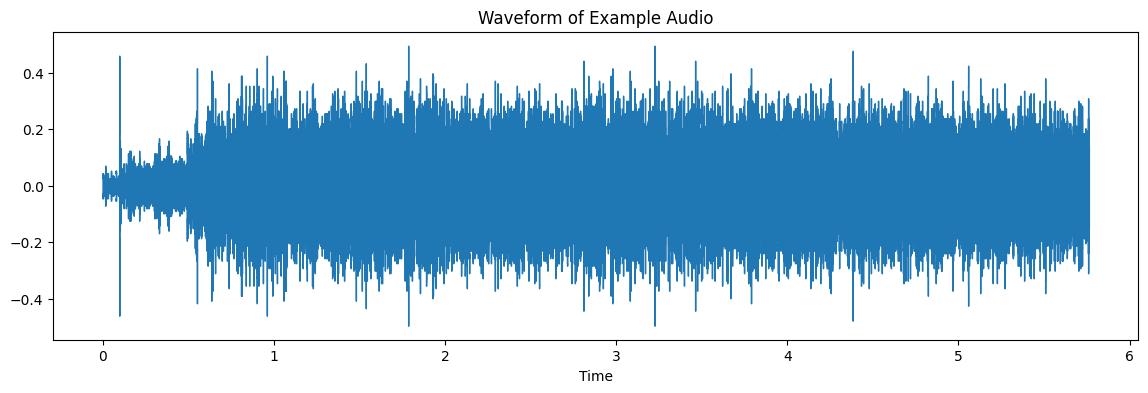

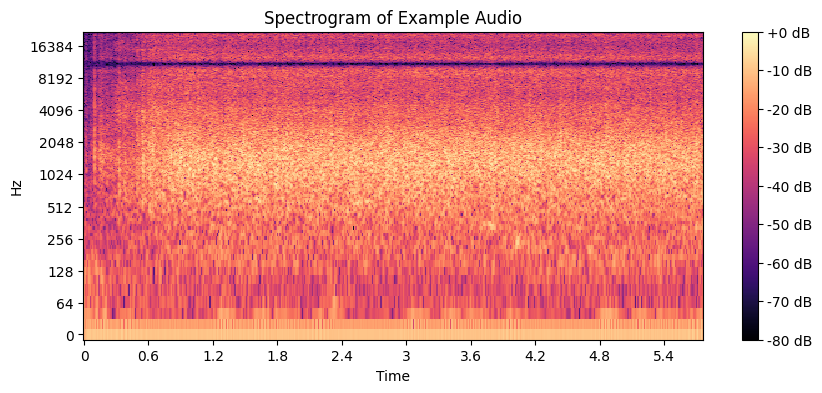

In [7]:
# Pick first example audio
first_row = train_csv.iloc[0]
example_audio = os.path.join(audio_path, first_row["label"], first_row["filename"])

# Load file
audio, sr = librosa.load(example_audio, sr=None)

# Waveform
plt.figure(figsize=(14, 4))
librosa.display.waveshow(audio, sr=sr)
plt.title('Waveform of Example Audio')
plt.show()

# Spectrogram
plt.figure(figsize=(10, 4))
spectrogram = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
librosa.display.specshow(spectrogram, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Example Audio')
plt.show()

In [8]:
X = np.array(features)
le = LabelEncoder()
y = to_categorical(le.fit_transform(labels))

# Train-Test Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Reshape for CNN
X_train = X_train.reshape(X_train.shape[0], 40, 1, 1)
X_val = X_val.reshape(X_val.shape[0], 40, 1, 1)

# CNN Model
model = Sequential()
model.add(Conv2D(32, (3, 1), activation='relu' , input_shape=(40, 1, 1)))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))

# Compile Model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train Model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=32)

C:\Users\sidiq\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 284ms/step - accuracy: 0.3333 - loss: 11.2109 - val_accuracy: 0.5000 - val_loss: 4.0854
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5000 - loss: 6.8570 - val_accuracy: 0.5714 - val_loss: 6.0736
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.6296 - loss: 5.8982 - val_accuracy: 0.5714 - val_loss: 3.7396
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6111 - loss: 4.3466 - val_accuracy: 0.5714 - val_loss: 2.0846
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6111 - loss: 3.2676 - val_accuracy: 0.7857 - val_loss: 1.4844
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5741 - loss: 2.9397 - val_accuracy: 0.7857 - val_loss: 1.3201
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5370 - loss: 2.6428 - val_accuracy: 0.7857 - val_loss: 1.0077
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.7222 - loss: 1.4438 - val_accuracy: 0.7143 - val_loss: 0.893

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7857 - loss: 0.7723
Validation Loss: 0.7723
Validation Accuracy: 0.7857
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step

Classification Report:
              precision    recall  f1-score   support

    approval       1.00      0.88      0.93         8
 disapproval       0.50      0.67      0.57         3
     neutral       0.67      0.67      0.67         3

    accuracy                           0.79        14
   macro avg       0.72      0.74      0.72        14
weighted avg       0.82      0.79      0.80        14



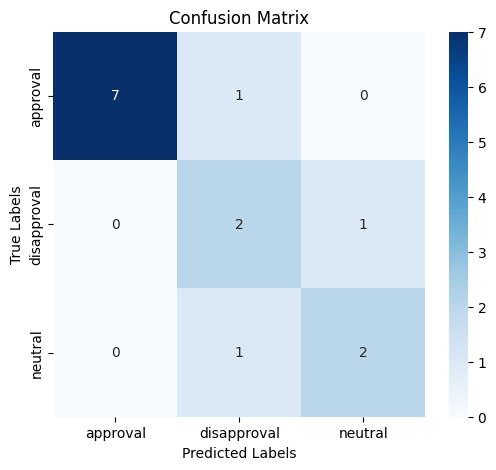

In [15]:
# Evaluate the Model
loss, accuracy = model.evaluate(X_val, y_val)
print(f'Validation Loss: {loss:.4f}')
print(f'Validation Accuracy: {accuracy:.4f}')

# Predict Classes
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

# Classification Report 
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

# Confusion Matrix 
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [16]:
from IPython.display import Audio  # For playing audio

# Detection System
def predict_sentiment(audio_path):
    feature = extract_features(audio_path)         # Extract MFCC features
    feature = feature.reshape(1, 40, 1, 1)         # Reshape for CNN input
    prediction = model.predict(feature)            # Predict sentiment
    predicted_label = le.inverse_transform([np.argmax(prediction)])[0]
    return predicted_label

In [17]:
#local Dataset 
Local_BASE =  r"C:\Users\sidiq\Desktop\FYP\Local_datasetV2"

local_features = []
local_labels = []

for label in ["approval", "disapproval", "neutral"]:
    folder = os.path.join(Local_BASE, label)

    for file in os.listdir(folder):
        if file.endswith(".wav"):
            filepath = os.path.join(folder, file)

            signal, sr = librosa.load(filepath, sr=None)

            feat = extract_features_from_signal(signal, sr)

            local_features.append(feat)
            local_labels.append(label)

X_local = np.array(local_features)

y_local = le.transform(local_labels)
y_local = to_categorical(y_local)

X_local = X_local.reshape(X_local.shape[0], X_local.shape[1], 1, 1)

In [18]:
#Retrain Model with local dataset
history_retrain = model.fit(
    X_local,
    y_local,
    epochs=100,
    batch_size=102
)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5312 - loss: 2.4066
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5781 - loss: 1.5253
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6042 - loss: 1.1341
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5938 - loss: 1.0920
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5208 - loss: 1.1115
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6458 - loss: 0.8337
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6615 - loss: 0.7516
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6875 - loss: 0.6990
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6458 - loss: 0.7526
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7135 - loss: 0.6602
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7240 - loss: 0.6523
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7240 - lo

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9271 - loss: 0.2169
Loss after retraining: 0.2168591022491455
Accuracy after retraining: 0.9270833134651184
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

Classification Report:
              precision    recall  f1-score   support

    approval       0.92      0.94      0.93        64
 disapproval       0.98      0.84      0.91        64
     neutral       0.89      1.00      0.94        64

    accuracy                           0.93       192
   macro avg       0.93      0.93      0.93       192
weighted avg       0.93      0.93      0.93       192



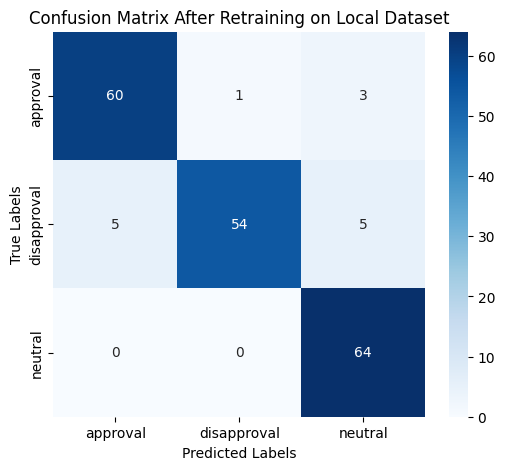

In [19]:
# EVALUATE AFTER RETRAINING ON LOCAL DATA

loss_after, acc_after = model.evaluate(X_local, y_local)
print("Loss after retraining:", loss_after)
print("Accuracy after retraining:", acc_after)

# Predict Classes on LOCAL DATA
y_pred = model.predict(X_local)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_local, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix After Retraining on Local Dataset')
plt.show()

In [20]:
audio, sr = librosa.load(r"C:\Users\sidiq\Downloads\IEEE dataport dataset crowd sound\IEEE dataport dataset crowd sound\step1 normalization\approval\appn0010.wav", sr=None)

segments, timestamps = segment_audio(audio, sr)

features = []
for seg in segments:
    feat = extract_features_from_signal(seg, sr)
    features.append(feat)

X = np.array(features)
X = X.reshape(X.shape[0], X.shape[1], 1, 1)

predictions = model.predict(X)
predicted_labels = le.inverse_transform(np.argmax(predictions, axis=1))

results = []
for time, label in zip(timestamps, predicted_labels):
    results.append({
        "start_time": time[0],
        "end_time": time[1],
        "emotion": label
    })

results


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


[{'start_time': 0.0, 'end_time': 3.0, 'emotion': np.str_('approval')}]

In [21]:
import pandas as pd

df = pd.DataFrame(results)
df["emotion"].value_counts(normalize=True) * 100

emotion
approval    100.0
Name: proportion, dtype: float64

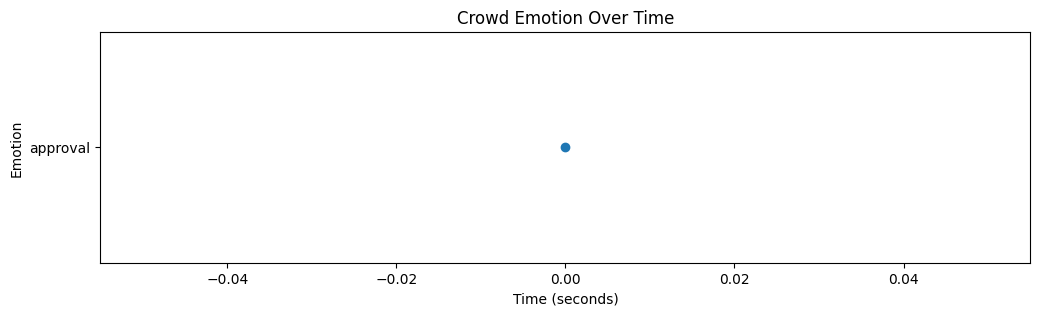

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))
plt.plot(df["start_time"], df["emotion"], marker="o")
plt.xlabel("Time (seconds)")
plt.ylabel("Emotion")
plt.title("Crowd Emotion Over Time")
plt.show()


In [23]:
audio, sr = librosa.load(r"C:\Users\sidiq\Desktop\FYP\Testing\test3\rec_0038.wav", sr=None)

segments, timestamps = segment_audio(audio, sr)

features = []
for seg in segments:
    feat = extract_features_from_signal(seg, sr)
    features.append(feat)

X = np.array(features)
X = X.reshape(X.shape[0], X.shape[1], 1, 1)

predictions = model.predict(X)
predicted_labels = le.inverse_transform(np.argmax(predictions, axis=1))

results = []
for time, label in zip(timestamps, predicted_labels):
    results.append({
        "start_time": time[0],
        "end_time": time[1],
        "emotion": label
    })

results



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


[{'start_time': 0.0, 'end_time': 3.0, 'emotion': np.str_('disapproval')},
 {'start_time': 3.0, 'end_time': 6.0, 'emotion': np.str_('disapproval')},
 {'start_time': 6.0, 'end_time': 9.0, 'emotion': np.str_('disapproval')},
 {'start_time': 9.0, 'end_time': 12.0, 'emotion': np.str_('disapproval')},
 {'start_time': 12.0, 'end_time': 15.0, 'emotion': np.str_('disapproval')},
 {'start_time': 15.0, 'end_time': 18.0, 'emotion': np.str_('disapproval')},
 {'start_time': 18.0, 'end_time': 21.0, 'emotion': np.str_('disapproval')},
 {'start_time': 21.0, 'end_time': 24.0, 'emotion': np.str_('disapproval')},
 {'start_time': 24.0, 'end_time': 27.0, 'emotion': np.str_('disapproval')},
 {'start_time': 27.0, 'end_time': 30.0, 'emotion': np.str_('disapproval')},
 {'start_time': 30.0, 'end_time': 33.0, 'emotion': np.str_('disapproval')},
 {'start_time': 33.0, 'end_time': 36.0, 'emotion': np.str_('disapproval')},
 {'start_time': 36.0, 'end_time': 39.0, 'emotion': np.str_('disapproval')},
 {'start_time': 39.

In [24]:
import pandas as pd

df = pd.DataFrame(results)
df["emotion"].value_counts(normalize=True) * 100

emotion
disapproval    100.0
Name: proportion, dtype: float64

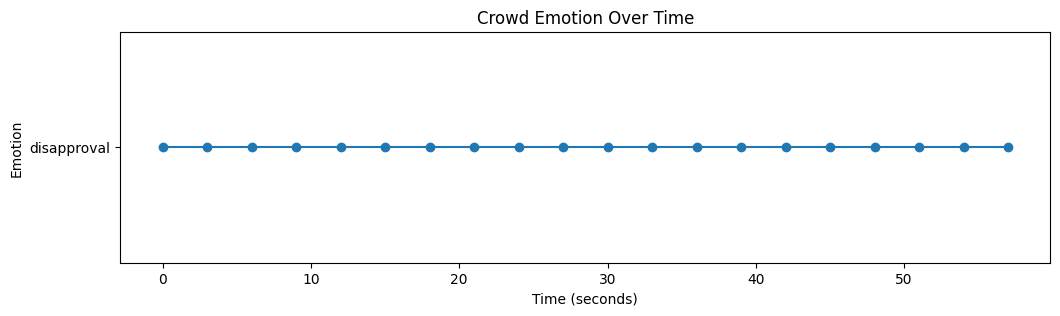

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))
plt.plot(df["start_time"], df["emotion"], marker="o")
plt.xlabel("Time (seconds)")
plt.ylabel("Emotion")
plt.title("Crowd Emotion Over Time")
plt.show()

In [26]:
audio, sr = librosa.load(r"C:\Users\sidiq\Desktop\FYP\Testing\test3\rec_0036.wav", sr=None)

segments, timestamps = segment_audio(audio, sr)

features = []
for seg in segments:
    feat = extract_features_from_signal(seg, sr)
    features.append(feat)

X = np.array(features)
X = X.reshape(X.shape[0], X.shape[1], 1, 1)

predictions = model.predict(X)
predicted_labels = le.inverse_transform(np.argmax(predictions, axis=1))

results = []
for time, label in zip(timestamps, predicted_labels):
    results.append({
        "start_time": time[0],
        "end_time": time[1],
        "emotion": label
    })

results



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


[{'start_time': 0.0, 'end_time': 3.0, 'emotion': np.str_('disapproval')},
 {'start_time': 3.0, 'end_time': 6.0, 'emotion': np.str_('disapproval')},
 {'start_time': 6.0, 'end_time': 9.0, 'emotion': np.str_('disapproval')},
 {'start_time': 9.0, 'end_time': 12.0, 'emotion': np.str_('disapproval')},
 {'start_time': 12.0, 'end_time': 15.0, 'emotion': np.str_('disapproval')},
 {'start_time': 15.0, 'end_time': 18.0, 'emotion': np.str_('disapproval')},
 {'start_time': 18.0, 'end_time': 21.0, 'emotion': np.str_('disapproval')},
 {'start_time': 21.0, 'end_time': 24.0, 'emotion': np.str_('disapproval')},
 {'start_time': 24.0, 'end_time': 27.0, 'emotion': np.str_('disapproval')},
 {'start_time': 27.0, 'end_time': 30.0, 'emotion': np.str_('disapproval')},
 {'start_time': 30.0, 'end_time': 33.0, 'emotion': np.str_('disapproval')},
 {'start_time': 33.0, 'end_time': 36.0, 'emotion': np.str_('disapproval')},
 {'start_time': 36.0, 'end_time': 39.0, 'emotion': np.str_('disapproval')},
 {'start_time': 39.

In [27]:
import pandas as pd

df = pd.DataFrame(results)
df["emotion"].value_counts(normalize=True) * 100

emotion
disapproval    100.0
Name: proportion, dtype: float64

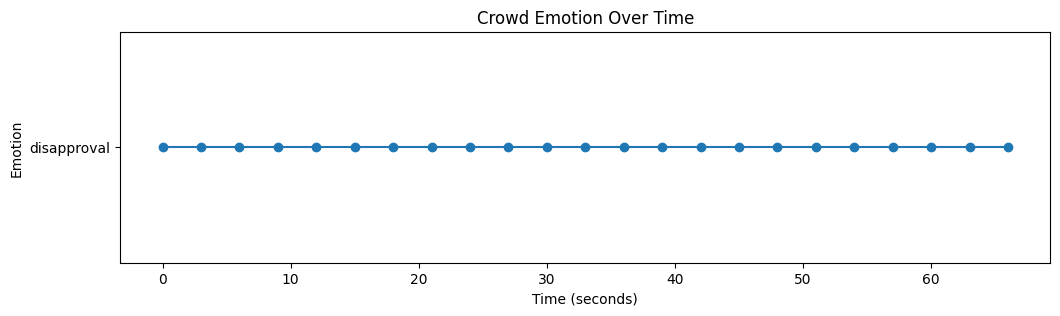

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))
plt.plot(df["start_time"], df["emotion"], marker="o")
plt.xlabel("Time (seconds)")
plt.ylabel("Emotion")
plt.title("Crowd Emotion Over Time")
plt.show()

Checking files...

Approval: C:\Users\sidiq\Downloads\IEEE dataport dataset crowd sound\IEEE dataport dataset crowd sound\step1 normalization\approval\appn0010.wav
Exists: True

Disapproval: C:\Users\sidiq\Downloads\IEEE dataport dataset crowd sound\IEEE dataport dataset crowd sound\step1 normalization\disapproval\booh0001.wav
Exists: True

Neutral: C:\Users\sidiq\Downloads\IEEE dataport dataset crowd sound\IEEE dataport dataset crowd sound\step1 normalization\neutral\neut0011.wav
Exists: True

PROCESSING: Approval


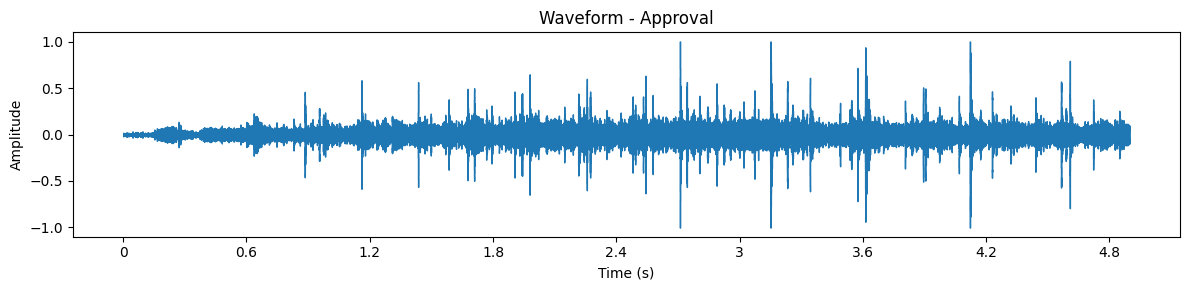

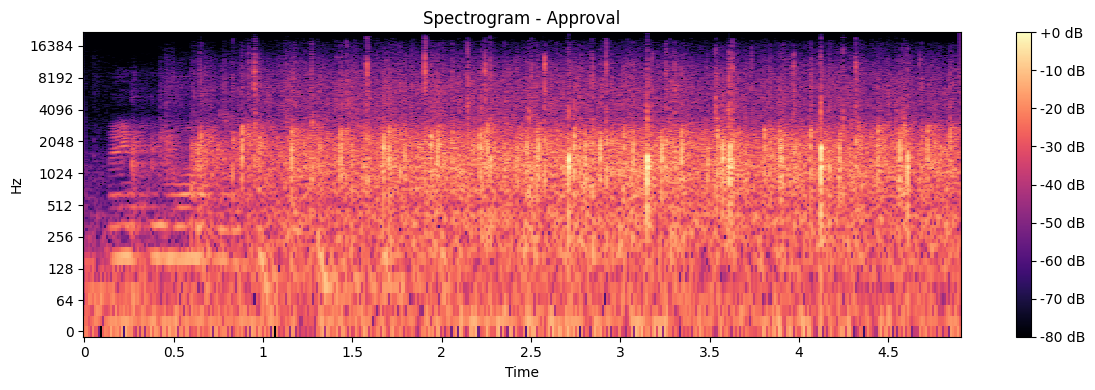

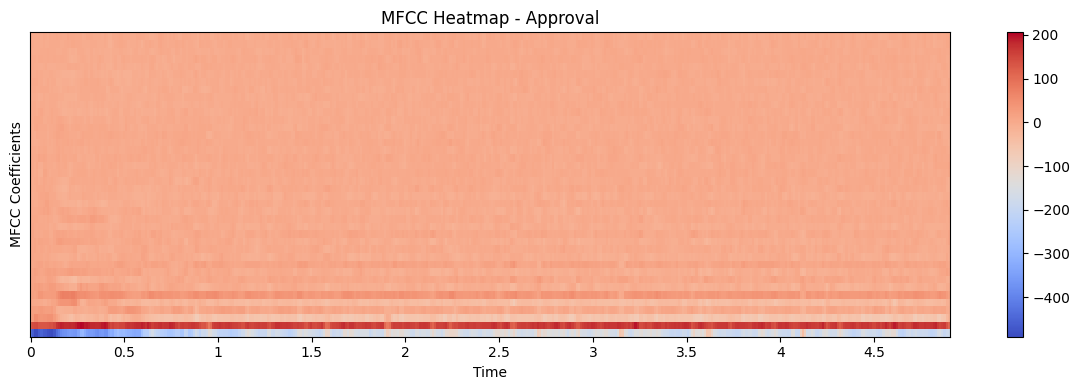

File: appn0010.wav
Sample rate: 44100
Duration: 4.899 s
MFCC matrix shape: (40, 423)
Final feature vector shape: (40,)
First 5 feature values: [-191.68051    160.87422    -48.12209      5.3090744  -28.070797 ]

PROCESSING: Disapproval


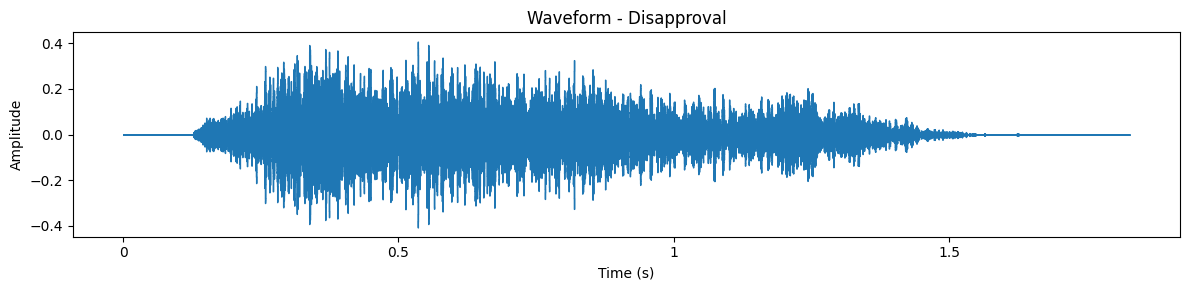

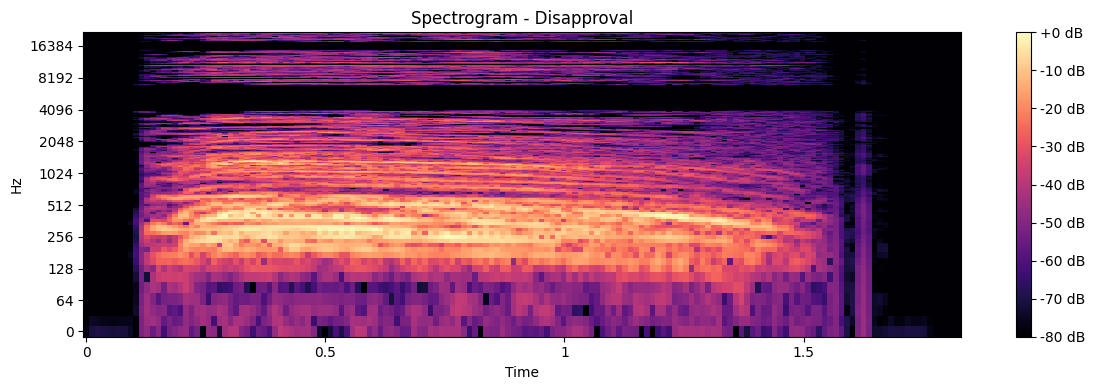

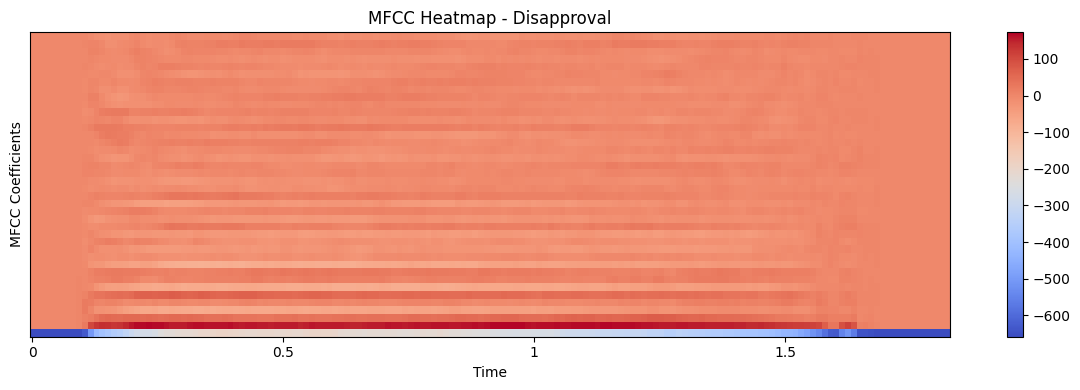

File: booh0001.wav
Sample rate: 44100
Duration: 1.829 s
MFCC matrix shape: (40, 158)
Final feature vector shape: (40,)
First 5 feature values: [-356.301      126.39832     37.873787   -34.886726     2.7737203]

PROCESSING: Neutral


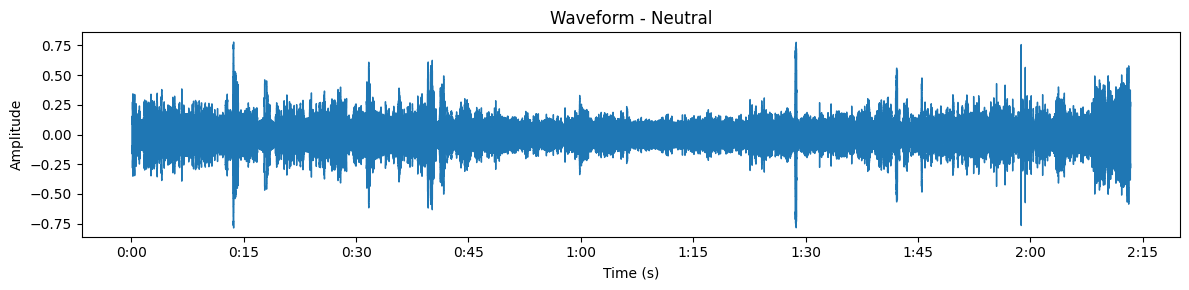

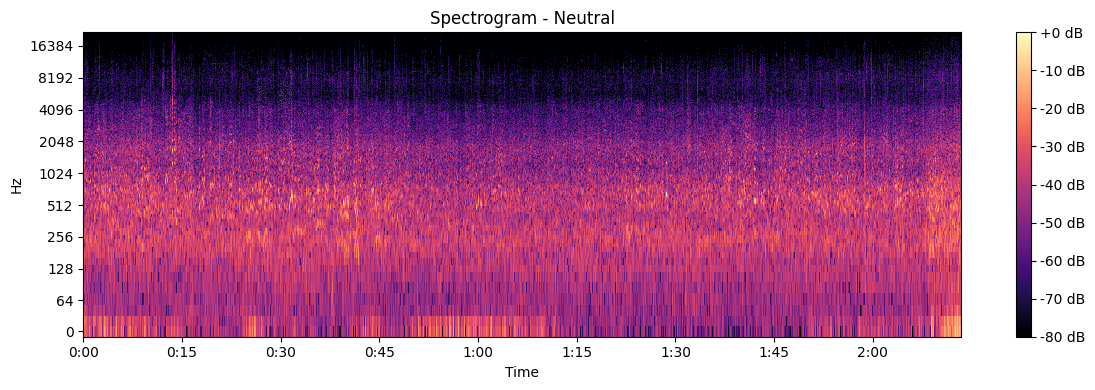

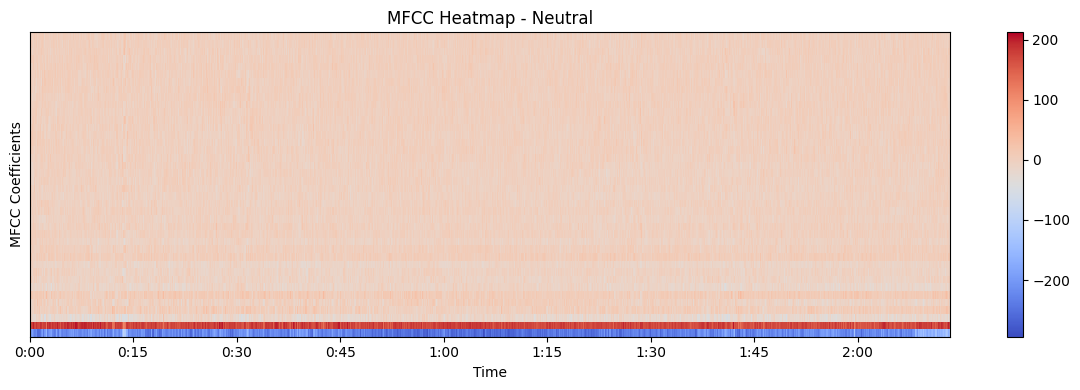

File: neut0011.wav
Sample rate: 44100
Duration: 133.358 s
MFCC matrix shape: (40, 11487)
Final feature vector shape: (40,)
First 5 feature values: [-225.00783    173.21622    -18.457527     2.9896827   -2.569942 ]



In [29]:
# TEST 1- feature extraction verification

import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

#Example from each class
samples = {
    "Approval": r"C:\Users\sidiq\Downloads\IEEE dataport dataset crowd sound\IEEE dataport dataset crowd sound\step1 normalization\approval\appn0010.wav",
    "Disapproval": r"C:\Users\sidiq\Downloads\IEEE dataport dataset crowd sound\IEEE dataport dataset crowd sound\step1 normalization\disapproval\booh0001.wav",
    "Neutral": r"C:\Users\sidiq\Downloads\IEEE dataport dataset crowd sound\IEEE dataport dataset crowd sound\step1 normalization\neutral\neut0011.wav",
}

#Check file
print("Checking files...\n")
for label, file_path in samples.items():
    exists = os.path.exists(file_path)
    print(f"{label}: {file_path}")
    print(f"Exists: {exists}\n")

if "extract_features_from_signal" not in globals():
    def extract_features_from_signal(signal, sr, n_mfcc=40):
        mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)
        mfccs_mean = np.mean(mfccs, axis=1)
        return mfccs_mean

#Run test
results = []

for label, file_path in samples.items():
    print("=" * 70)
    print(f"PROCESSING: {label}")
    
    audio, sr = librosa.load(file_path, sr=None)
    duration = len(audio) / sr
    
    # Waveform
    plt.figure(figsize=(12, 3))
    librosa.display.waveshow(audio, sr=sr)
    plt.title(f"Waveform - {label}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

    # Spectrogram
    plt.figure(figsize=(12, 4))
    S_db = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
    librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="log")
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"Spectrogram - {label}")
    plt.tight_layout()
    plt.show()

    # MFCC heatmap
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    plt.figure(figsize=(12, 4))
    librosa.display.specshow(mfccs, sr=sr, x_axis="time")
    plt.colorbar()
    plt.title(f"MFCC Heatmap - {label}")
    plt.xlabel("Time")
    plt.ylabel("MFCC Coefficients")
    plt.tight_layout()
    plt.show()

    # Final feature vector
    feature_vector = extract_features_from_signal(audio, sr)

    print(f"File: {os.path.basename(file_path)}")
    print(f"Sample rate: {sr}")
    print(f"Duration: {duration:.3f} s")
    print(f"MFCC matrix shape: {mfccs.shape}")
    print(f"Final feature vector shape: {feature_vector.shape}")
    print(f"First 5 feature values: {feature_vector[:5]}")
    print()

    results.append({
        "Class": label,
        "Filename": os.path.basename(file_path),
        "Sample Rate": sr,
        "Duration (s)": round(duration, 3),
        "MFCC Matrix Shape": str(mfccs.shape),
        "Final Feature Shape": str(feature_vector.shape)
    })


PUBLIC DATASET CLASS DISTRIBUTION
Dataset path: C:\Users\sidiq\Downloads\IEEE dataport dataset crowd sound\IEEE dataport dataset crowd sound\step1 normalization
Total samples: 68



,Class,Number of Samples,Percentage (%)
0,Approval,39,57.35
1,Disapproval,14,20.59
2,Neutral,15,22.06


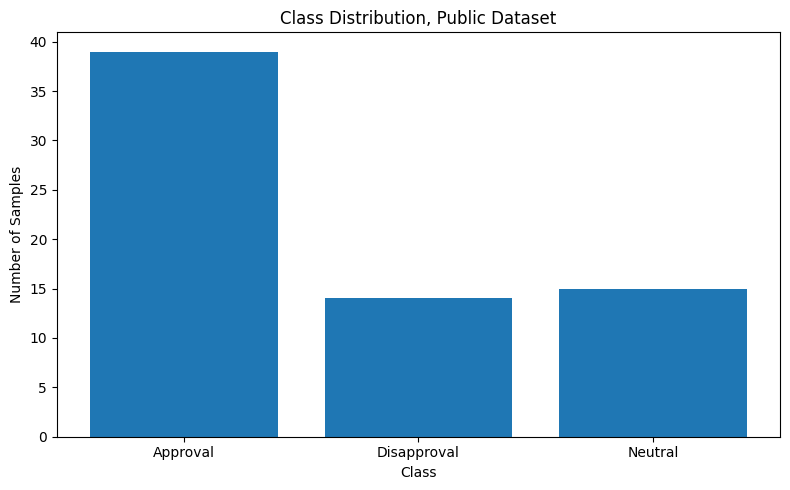


LOCAL DATASET CLASS DISTRIBUTION
Dataset path: C:\Users\sidiq\Desktop\FYP\Local_DatasetV2
Total samples: 192



,Class,Number of Samples,Percentage (%)
0,Approval,64,33.33
1,Disapproval,64,33.33
2,Neutral,64,33.33


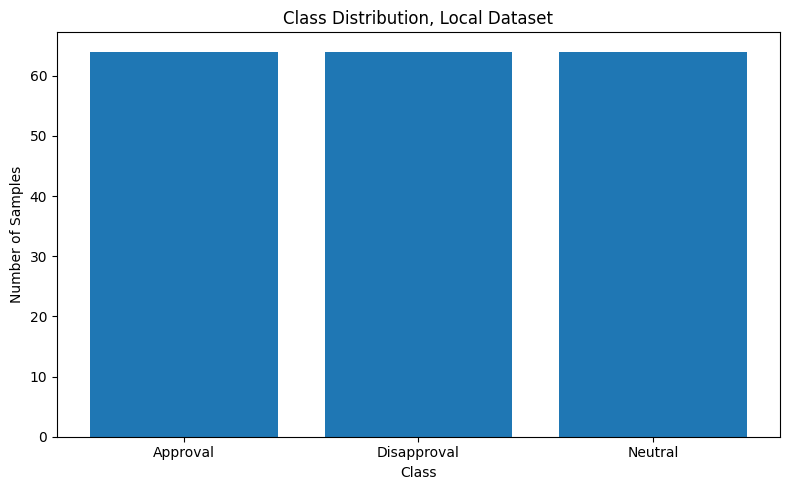

In [30]:
# TEST 2 - CLASS DISTRIBUTION FOR PUBLIC AND LOCAL DATASETS

import os
import pandas as pd
import matplotlib.pyplot as plt

class_names = ["approval", "disapproval", "neutral"]

public_path = r"C:\Users\sidiq\Downloads\IEEE dataport dataset crowd sound\IEEE dataport dataset crowd sound\step1 normalization"
local_path = r"C:\Users\sidiq\Desktop\FYP\Local_DatasetV2"

def class_distribution(base_path, dataset_name):
    rows = []

    for class_name in class_names:
        folder = os.path.join(base_path, class_name)
        count = len([f for f in os.listdir(folder) if f.lower().endswith(".wav")]) if os.path.exists(folder) else 0
        rows.append([class_name.capitalize(), count])

    df = pd.DataFrame(rows, columns=["Class", "Number of Samples"])
    total = df["Number of Samples"].sum()
    df["Percentage (%)"] = (df["Number of Samples"] / total * 100).round(2) if total > 0 else 0

    print(f"\n{'='*60}")
    print(f"{dataset_name.upper()} CLASS DISTRIBUTION")
    print(f"{'='*60}")
    print(f"Dataset path: {base_path}")
    print(f"Total samples: {total}\n")
    display(df)

    plt.figure(figsize=(8, 5))
    plt.bar(df["Class"], df["Number of Samples"])
    plt.title(f"Class Distribution, {dataset_name}")
    plt.xlabel("Class")
    plt.ylabel("Number of Samples")
    plt.tight_layout()
    plt.show()

    return df

df_public = class_distribution(public_path, "Public Dataset")
df_local = class_distribution(local_path, "Local Dataset")

In [31]:
# TEST 3 - TRAINING PERFORMANCE VERIFICATION FOR BOTH MODELS

import pandas as pd
import matplotlib.pyplot as plt

def show_training_performance(history_obj, model_name):
    hist_dict = history_obj.history

    print(f"\n{model_name}")
    print("Available history keys:")
    print(hist_dict.keys())

    epochs = list(range(1, len(hist_dict['accuracy']) + 1))

    # Accuracy plot
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist_dict['accuracy'], label='Training Accuracy')

    if 'val_accuracy' in hist_dict:
        plt.plot(epochs, hist_dict['val_accuracy'], label='Validation Accuracy')

    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Loss plot
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist_dict['loss'], label='Training Loss')

    if 'val_loss' in hist_dict:
        plt.plot(epochs, hist_dict['val_loss'], label='Validation Loss')

    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Summary table
    summary_data = {
        'Epoch': epochs,
        'Training Accuracy': hist_dict['accuracy'],
        'Training Loss': hist_dict['loss']
    }

    if 'val_accuracy' in hist_dict:
        summary_data['Validation Accuracy'] = hist_dict['val_accuracy']

    if 'val_loss' in hist_dict:
        summary_data['Validation Loss'] = hist_dict['val_loss']

    summary_df = pd.DataFrame(summary_data)
    display(summary_df)
    return summary_df


Public Dataset Model
Available history keys:
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


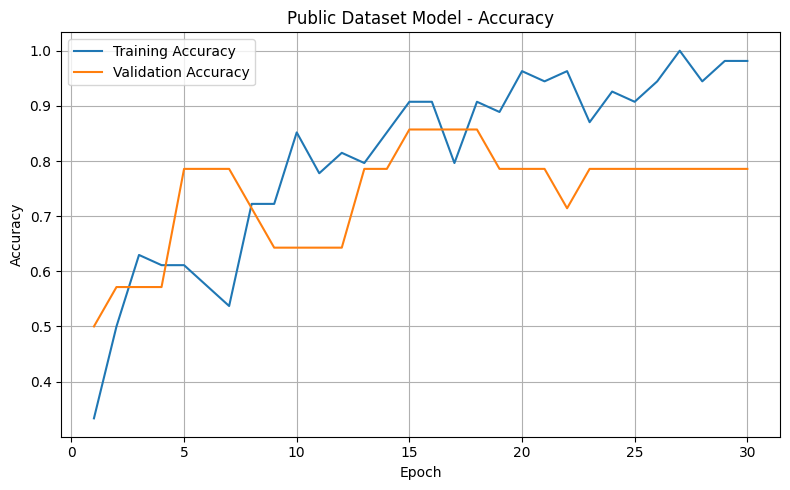

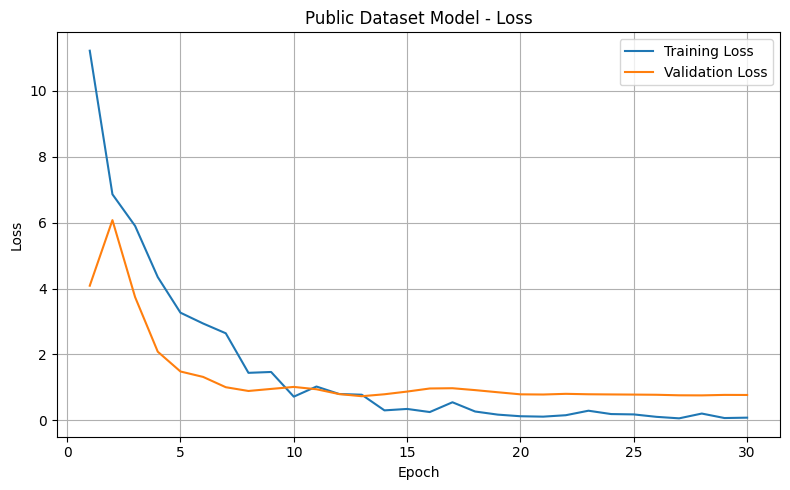

,Epoch,Training Accuracy,Training Loss,Validation Accuracy,Validation Loss
0,1,0.333333,11.210903,0.500000,4.085369
1,2,0.500000,6.856958,0.571429,6.073619
2,3,0.629630,5.898166,0.571429,3.739625
3,4,0.611111,4.346626,0.571429,2.084579
4,5,0.611111,3.267602,0.785714,1.484387
5,6,0.574074,2.939688,0.785714,1.320058
6,7,0.537037,2.642830,0.785714,1.007665
7,8,0.722222,1.443767,0.714286,0.893603
8,9,0.722222,1.469758,0.642857,0.955920
9,10,0.851852,0.721372,0.642857,1.016541



Retrained Model with Local Data
Available history keys:
dict_keys(['accuracy', 'loss'])


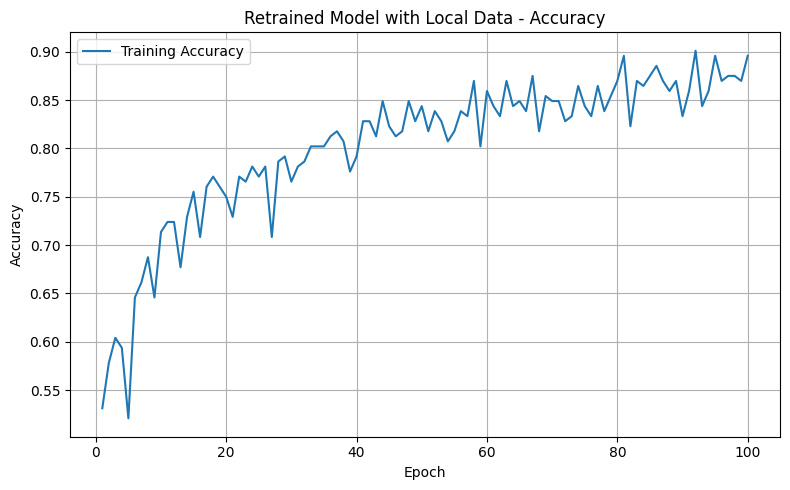

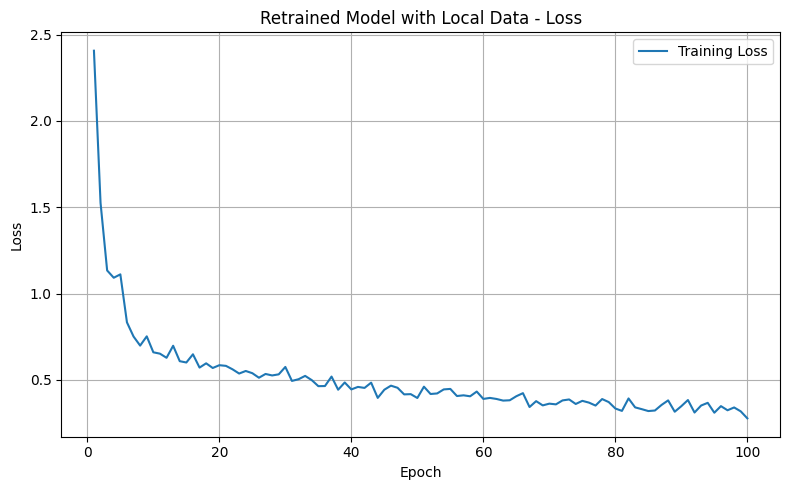

,Epoch,Training Accuracy,Training Loss
0,1,0.531250,2.406625
1,2,0.578125,1.525268
2,3,0.604167,1.134113
3,4,0.593750,1.091954
4,5,0.520833,1.111520
...,...,...,...
95,96,0.869792,0.348487
96,97,0.875000,0.324580
97,98,0.875000,0.340822
98,99,0.869792,0.318292


In [32]:
public_summary = show_training_performance(history, "Public Dataset Model")
retrain_summary = show_training_performance(history_retrain, "Retrained Model with Local Data")

In [33]:
# real world test (200 meter race female)
audio, sr = librosa.load(r"C:\Users\sidiq\Desktop\FYP\Testing\Real world testing\rec_0047.wav", sr=None)

segments, timestamps = segment_audio(audio, sr)

features = []
for seg in segments:
    feat = extract_features_from_signal(seg, sr)
    features.append(feat)

X = np.array(features)
X = X.reshape(X.shape[0], X.shape[1], 1, 1)

predictions = model.predict(X)
predicted_labels = le.inverse_transform(np.argmax(predictions, axis=1))

results = []
for time, label in zip(timestamps, predicted_labels):
    results.append({
        "start_time": time[0],
        "end_time": time[1],
        "emotion": label
    })

results



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


[{'start_time': 0.0, 'end_time': 3.0, 'emotion': np.str_('approval')},
 {'start_time': 3.0, 'end_time': 6.0, 'emotion': np.str_('approval')},
 {'start_time': 6.0, 'end_time': 9.0, 'emotion': np.str_('approval')},
 {'start_time': 9.0, 'end_time': 12.0, 'emotion': np.str_('approval')},
 {'start_time': 12.0, 'end_time': 15.0, 'emotion': np.str_('approval')},
 {'start_time': 15.0, 'end_time': 18.0, 'emotion': np.str_('approval')},
 {'start_time': 18.0, 'end_time': 21.0, 'emotion': np.str_('approval')}]

In [34]:
import pandas as pd

df = pd.DataFrame(results)
df["emotion"].value_counts(normalize=True) * 100

emotion
approval    100.0
Name: proportion, dtype: float64

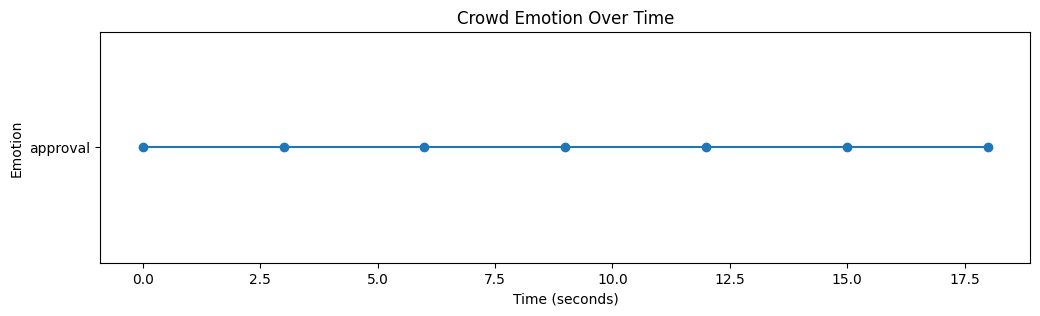

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))
plt.plot(df["start_time"], df["emotion"], marker="o")
plt.xlabel("Time (seconds)")
plt.ylabel("Emotion")
plt.title("Crowd Emotion Over Time")
plt.show()

In [36]:
# real world test (Tug of war)
audio, sr = librosa.load(r"C:\Users\sidiq\Desktop\FYP\Testing\Real world testing\rec_0048.wav", sr=None)

segments, timestamps = segment_audio(audio, sr)

features = []
for seg in segments:
    feat = extract_features_from_signal(seg, sr)
    features.append(feat)

X = np.array(features)
X = X.reshape(X.shape[0], X.shape[1], 1, 1)

predictions = model.predict(X)
predicted_labels = le.inverse_transform(np.argmax(predictions, axis=1))

results = []
for time, label in zip(timestamps, predicted_labels):
    results.append({
        "start_time": time[0],
        "end_time": time[1],
        "emotion": label
    })

results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


[{'start_time': 0.0, 'end_time': 3.0, 'emotion': np.str_('disapproval')},
 {'start_time': 3.0, 'end_time': 6.0, 'emotion': np.str_('neutral')},
 {'start_time': 6.0, 'end_time': 9.0, 'emotion': np.str_('neutral')},
 {'start_time': 9.0, 'end_time': 12.0, 'emotion': np.str_('neutral')},
 {'start_time': 12.0, 'end_time': 15.0, 'emotion': np.str_('neutral')},
 {'start_time': 15.0, 'end_time': 18.0, 'emotion': np.str_('disapproval')},
 {'start_time': 18.0, 'end_time': 21.0, 'emotion': np.str_('neutral')},
 {'start_time': 21.0, 'end_time': 24.0, 'emotion': np.str_('neutral')},
 {'start_time': 24.0, 'end_time': 27.0, 'emotion': np.str_('neutral')},
 {'start_time': 27.0, 'end_time': 30.0, 'emotion': np.str_('neutral')},
 {'start_time': 30.0, 'end_time': 33.0, 'emotion': np.str_('disapproval')},
 {'start_time': 33.0, 'end_time': 36.0, 'emotion': np.str_('neutral')},
 {'start_time': 36.0, 'end_time': 39.0, 'emotion': np.str_('neutral')},
 {'start_time': 39.0, 'end_time': 42.0, 'emotion': np.str_(

In [37]:
import pandas as pd

df = pd.DataFrame(results)
df["emotion"].value_counts(normalize=True) * 100

emotion
neutral        50.000
approval       34.375
disapproval    15.625
Name: proportion, dtype: float64

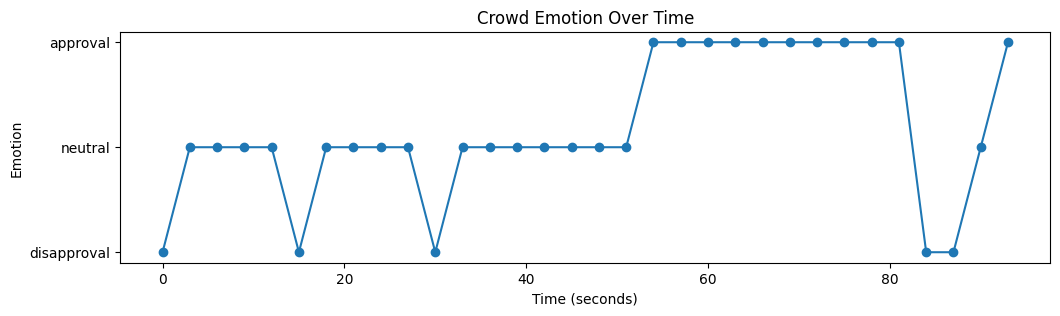

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))
plt.plot(df["start_time"], df["emotion"], marker="o")
plt.xlabel("Time (seconds)")
plt.ylabel("Emotion")
plt.title("Crowd Emotion Over Time")
plt.show()

In [39]:
# real world test (rely race)
audio, sr = librosa.load(r"C:\Users\sidiq\Desktop\FYP\Testing\Real world testing\rec_0049.wav", sr=None)

segments, timestamps = segment_audio(audio, sr)

features = []
for seg in segments:
    feat = extract_features_from_signal(seg, sr)
    features.append(feat)

X = np.array(features)
X = X.reshape(X.shape[0], X.shape[1], 1, 1)

predictions = model.predict(X)
predicted_labels = le.inverse_transform(np.argmax(predictions, axis=1))

results = []
for time, label in zip(timestamps, predicted_labels):
    results.append({
        "start_time": time[0],
        "end_time": time[1],
        "emotion": label
    })

results

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


[{'start_time': 0.0, 'end_time': 3.0, 'emotion': np.str_('neutral')},
 {'start_time': 3.0, 'end_time': 6.0, 'emotion': np.str_('neutral')},
 {'start_time': 6.0, 'end_time': 9.0, 'emotion': np.str_('neutral')},
 {'start_time': 9.0, 'end_time': 12.0, 'emotion': np.str_('neutral')},
 {'start_time': 12.0, 'end_time': 15.0, 'emotion': np.str_('neutral')},
 {'start_time': 15.0, 'end_time': 18.0, 'emotion': np.str_('neutral')},
 {'start_time': 18.0, 'end_time': 21.0, 'emotion': np.str_('neutral')},
 {'start_time': 21.0, 'end_time': 24.0, 'emotion': np.str_('neutral')},
 {'start_time': 24.0, 'end_time': 27.0, 'emotion': np.str_('disapproval')},
 {'start_time': 27.0, 'end_time': 30.0, 'emotion': np.str_('neutral')},
 {'start_time': 30.0, 'end_time': 33.0, 'emotion': np.str_('neutral')},
 {'start_time': 33.0, 'end_time': 36.0, 'emotion': np.str_('neutral')},
 {'start_time': 36.0, 'end_time': 39.0, 'emotion': np.str_('neutral')},
 {'start_time': 39.0, 'end_time': 42.0, 'emotion': np.str_('neutral

In [40]:
import pandas as pd

df = pd.DataFrame(results)
df["emotion"].value_counts(normalize=True) * 100

emotion
neutral        80.281690
disapproval    14.084507
approval        5.633803
Name: proportion, dtype: float64

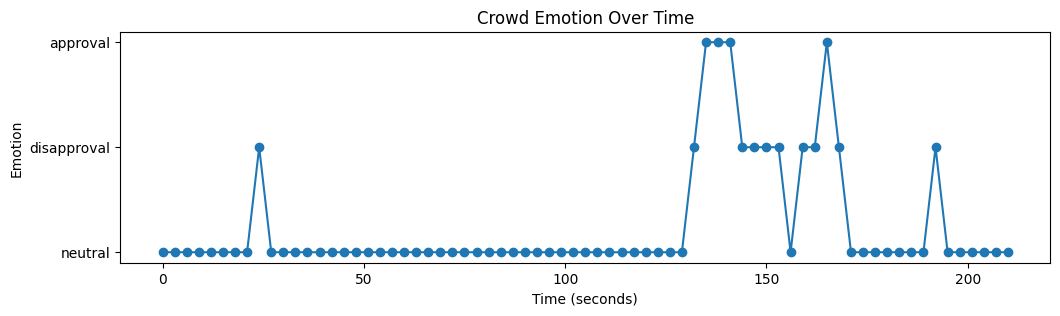

In [41]:
plt.figure(figsize=(12, 3))
plt.plot(df["start_time"], df["emotion"], marker="o")
plt.xlabel("Time (seconds)")
plt.ylabel("Emotion")
plt.title("Crowd Emotion Over Time")
plt.show()

In [42]:
# real world test (5 leg race)
audio, sr = librosa.load(r"C:\Users\sidiq\Desktop\FYP\Testing\Real world testing\rec_0050.wav", sr=None)

segments, timestamps = segment_audio(audio, sr)

features = []
for seg in segments:
    feat = extract_features_from_signal(seg, sr)
    features.append(feat)

X = np.array(features)
X = X.reshape(X.shape[0], X.shape[1], 1, 1)

predictions = model.predict(X)
predicted_labels = le.inverse_transform(np.argmax(predictions, axis=1))

results = []
for time, label in zip(timestamps, predicted_labels):
    results.append({
        "start_time": time[0],
        "end_time": time[1],
        "emotion": label
    })

results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


[{'start_time': 0.0, 'end_time': 3.0, 'emotion': np.str_('approval')},
 {'start_time': 3.0, 'end_time': 6.0, 'emotion': np.str_('approval')},
 {'start_time': 6.0, 'end_time': 9.0, 'emotion': np.str_('neutral')},
 {'start_time': 9.0, 'end_time': 12.0, 'emotion': np.str_('neutral')},
 {'start_time': 12.0, 'end_time': 15.0, 'emotion': np.str_('disapproval')},
 {'start_time': 15.0, 'end_time': 18.0, 'emotion': np.str_('disapproval')},
 {'start_time': 18.0, 'end_time': 21.0, 'emotion': np.str_('neutral')},
 {'start_time': 21.0, 'end_time': 24.0, 'emotion': np.str_('neutral')}]

In [43]:
df = pd.DataFrame(results)
df["emotion"].value_counts(normalize=True) * 100

emotion
neutral        50.0
approval       25.0
disapproval    25.0
Name: proportion, dtype: float64

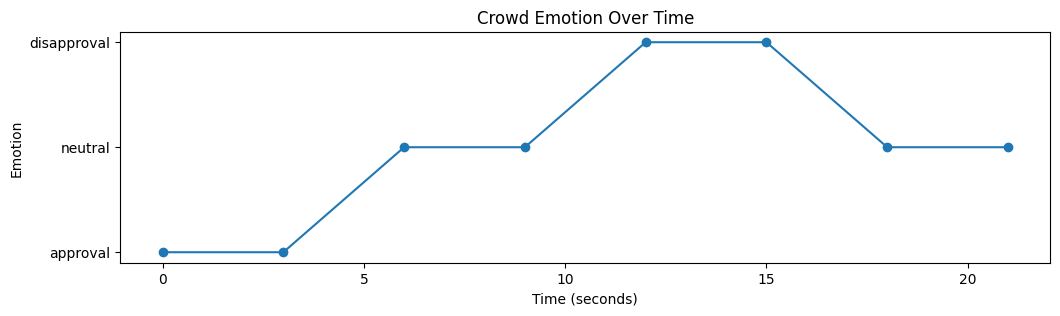

In [44]:
plt.figure(figsize=(12, 3))
plt.plot(df["start_time"], df["emotion"], marker="o")
plt.xlabel("Time (seconds)")
plt.ylabel("Emotion")
plt.title("Crowd Emotion Over Time")
plt.show()

In [45]:
# real world test (Hula Hoop race)
audio, sr = librosa.load(r"C:\Users\sidiq\Desktop\FYP\Testing\Real world testing\rec_0051.wav", sr=None)

segments, timestamps = segment_audio(audio, sr)

features = []
for seg in segments:
    feat = extract_features_from_signal(seg, sr)
    features.append(feat)

X = np.array(features)
X = X.reshape(X.shape[0], X.shape[1], 1, 1)

predictions = model.predict(X)
predicted_labels = le.inverse_transform(np.argmax(predictions, axis=1))

results = []
for time, label in zip(timestamps, predicted_labels):
    results.append({
        "start_time": time[0],
        "end_time": time[1],
        "emotion": label
    })

results

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


[{'start_time': 0.0, 'end_time': 3.0, 'emotion': np.str_('neutral')},
 {'start_time': 3.0, 'end_time': 6.0, 'emotion': np.str_('disapproval')},
 {'start_time': 6.0, 'end_time': 9.0, 'emotion': np.str_('disapproval')},
 {'start_time': 9.0, 'end_time': 12.0, 'emotion': np.str_('disapproval')},
 {'start_time': 12.0, 'end_time': 15.0, 'emotion': np.str_('disapproval')},
 {'start_time': 15.0, 'end_time': 18.0, 'emotion': np.str_('disapproval')},
 {'start_time': 18.0, 'end_time': 21.0, 'emotion': np.str_('disapproval')},
 {'start_time': 21.0, 'end_time': 24.0, 'emotion': np.str_('neutral')},
 {'start_time': 24.0, 'end_time': 27.0, 'emotion': np.str_('disapproval')},
 {'start_time': 27.0, 'end_time': 30.0, 'emotion': np.str_('neutral')},
 {'start_time': 30.0, 'end_time': 33.0, 'emotion': np.str_('neutral')},
 {'start_time': 33.0, 'end_time': 36.0, 'emotion': np.str_('neutral')},
 {'start_time': 36.0, 'end_time': 39.0, 'emotion': np.str_('neutral')},
 {'start_time': 39.0, 'end_time': 42.0, 'em

In [46]:
df = pd.DataFrame(results)
df["emotion"].value_counts(normalize=True) * 100

emotion
disapproval    38.0
approval       34.0
neutral        28.0
Name: proportion, dtype: float64

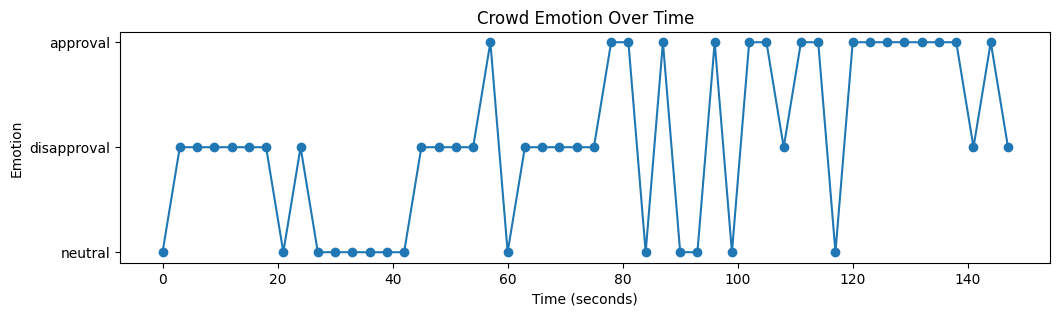

In [47]:
plt.figure(figsize=(12, 3))
plt.plot(df["start_time"], df["emotion"], marker="o")
plt.xlabel("Time (seconds)")
plt.ylabel("Emotion")
plt.title("Crowd Emotion Over Time")
plt.show()